In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder ,StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report ,confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime

In [2]:
jap = pd.read_excel("JPN Data.xlsx")
ind = pd.read_excel("IN_Data.xlsx")

In [3]:
l = LabelEncoder()
jap['GENDER'] =l.fit_transform(jap['GENDER'])#M=1 F =0
#select feature and target
X_jap = jap[['CURR_AGE','GENDER','ANN_INCOME','AGE_CAR']]
Y_jap = jap['PURCHASE']
#scale features
scaler = StandardScaler()
X_jap_scale = scaler.fit_transform(X_jap)

In [4]:
model = LogisticRegression()
model.fit(X_jap_scale,Y_jap)

LogisticRegression()

Classification Report(Japanese Dataset)
              precision    recall  f1-score   support

           0       0.64      0.53      0.58     16969
           1       0.69      0.78      0.73     23031

    accuracy                           0.67     40000
   macro avg       0.67      0.66      0.66     40000
weighted avg       0.67      0.67      0.67     40000



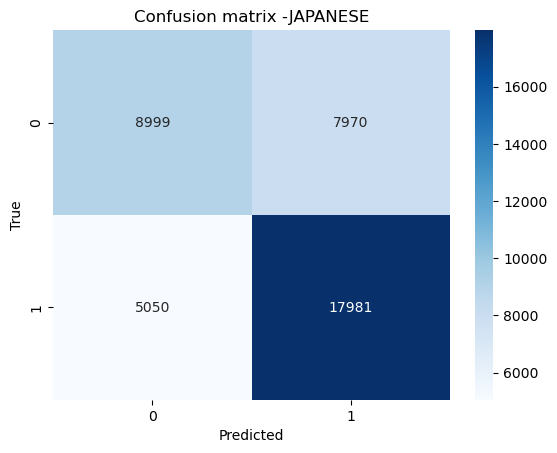

In [5]:
#model prediction on japanese data set
y = model.predict(X_jap_scale)

#evaluation metrics
print("Classification Report(Japanese Dataset)")
print(classification_report(Y_jap , y))
#Confusion metric
cm = confusion_matrix(Y_jap , y)
sns.heatmap(cm ,annot = True ,fmt = 'd' , cmap = 'Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion matrix -JAPANESE")
plt.show()

In [6]:
#coefficient +ve increase likelihood of buying -ve decrease likelihood of buying
coeff = pd.DataFrame({
    'Feature':['CURR_AGE','GENDER(M=1)','ANN_INCOME','AGE_CAR'],
    'Coefficient':model.coef_[0]
})
print(coeff)
#interpration
for index , row in coeff.iterrows():
    direction = "increases" if row['Coefficient'] > 0 else "decrease"
    print(f"-A higher {row['Feature']} {direction} the likelihood of purchasing car")

       Feature  Coefficient
0     CURR_AGE    -0.141549
1  GENDER(M=1)     0.112712
2   ANN_INCOME     0.418471
3      AGE_CAR     0.851503
-A higher CURR_AGE decrease the likelihood of purchasing car
-A higher GENDER(M=1) increases the likelihood of purchasing car
-A higher ANN_INCOME increases the likelihood of purchasing car
-A higher AGE_CAR increases the likelihood of purchasing car


In [7]:
ind

,ID,CURR_AGE,GENDER,ANN_INCOME,DT_MAINT
0,20710B05XL,54,M,1425390,2018-04-20
1,89602T51HX,47,M,1678954,2018-06-08
2,70190Z52IP,60,M,931624,2017-07-31
3,25623V15MU,55,F,1106320,2017-07-31
4,36230I68CE,32,F,748465,2019-01-27
...,...,...,...,...,...
69995,35280V26PS,49,F,861770,2018-04-08
69996,79863N01VR,59,M,888976,2018-05-17
69997,94236O99QE,33,M,699676,2019-04-21
69998,23696V12DP,41,M,1881922,2018-07-14


In [8]:
ind['GENDER'] =l.transform(ind['GENDER'])#M=1 F =0


In [9]:
ind

,ID,CURR_AGE,GENDER,ANN_INCOME,DT_MAINT
0,20710B05XL,54,1,1425390,2018-04-20
1,89602T51HX,47,1,1678954,2018-06-08
2,70190Z52IP,60,1,931624,2017-07-31
3,25623V15MU,55,0,1106320,2017-07-31
4,36230I68CE,32,0,748465,2019-01-27
...,...,...,...,...,...
69995,35280V26PS,49,0,861770,2018-04-08
69996,79863N01VR,59,1,888976,2018-05-17
69997,94236O99QE,33,1,699676,2019-04-21
69998,23696V12DP,41,1,1881922,2018-07-14


In [10]:
ind['AGE_CAR'] = (pd.to_datetime('2025-01-01') - ind['DT_MAINT']).dt.days
X_ind = ind[['CURR_AGE', 'GENDER', 'ANN_INCOME', 'AGE_CAR']]
X_ind_scaled = scaler.transform(X_ind)

In [11]:
# Predict on Indian dataset
ind['PRED_PURCHASE'] = model.predict(X_ind_scaled)

In [12]:
potential_buyers = ind['PRED_PURCHASE'].sum()
print(f"✅ Potential Buyers in Indian Market: {potential_buyers} out of {len(ind)}")

✅ Potential Buyers in Indian Market: 70000 out of 70000


In [13]:
#Export for Powerbi
ind.to_csv("Indian_Predictions.csv", index=False)

In [28]:
ind

,ID,CURR_AGE,GENDER,ANN_INCOME,DT_MAINT,AGE_CAR,PRED_PURCHASE
0,20710B05XL,54,1,1425390,2018-04-20,2448,1
1,89602T51HX,47,1,1678954,2018-06-08,2399,1
2,70190Z52IP,60,1,931624,2017-07-31,2711,1
3,25623V15MU,55,0,1106320,2017-07-31,2711,1
4,36230I68CE,32,0,748465,2019-01-27,2166,1
...,...,...,...,...,...,...,...
69995,35280V26PS,49,0,861770,2018-04-08,2460,1
69996,79863N01VR,59,1,888976,2018-05-17,2421,1
69997,94236O99QE,33,1,699676,2019-04-21,2082,1
69998,23696V12DP,41,1,1881922,2018-07-14,2363,1


In [32]:
jap.to_csv("japanese.csv",index = False)